# Pneumonia Detection from Chest X-rays (CNN)

- **Goal:** Detect pneumonia from chest X-ray images using Convolutional Neural Networks.
- **Dataset:** Chest X-ray dataset (train/val/test split).
- **Approach:** Preprocessing, augmentation, CNN training, evaluation with clinical metrics.
- **Impact:** Supports early diagnosis and AI-assisted screening.

## Importing Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve

## Data Processing Function (Train/Val/Test)

- Preprocess images (resize, normalize).
- Apply augmentation (zoom, flip).
- Prepare train/val/test generators and arrays for evaluation.

In [ ]:
def process_data(img_dims=150, batch_size=16):
    train_datagen = ImageDataGenerator(rescale=1./255, zoom_range=0.3, vertical_flip=True)
    val_datagen   = ImageDataGenerator(rescale=1./255)
    test_datagen  = ImageDataGenerator(rescale=1./255)
    
    train_generator = train_datagen.flow_from_directory(
        'chest_xray/train/',
        target_size=(img_dims, img_dims),
        batch_size=batch_size,
        class_mode='binary',
        shuffle=True
    )
    
    val_generator = val_datagen.flow_from_directory(
        'chest_xray/validation/',
        target_size=(img_dims, img_dims),
        batch_size=batch_size,
        class_mode='binary',
        shuffle=True
    )
    
    test_generator = test_datagen.flow_from_directory(
        'chest_xray/test/',
        target_size=(img_dims, img_dims),
        batch_size=batch_size,
        class_mode='binary',
        shuffle=True
    )
    
    # Manual test set arrays for evaluation
    testData, testLabels = [], []
    for condition in ['NORMAL', 'PNEUMONIA']:
        for img_name in os.listdir(f'chest_xray/test/{condition}'):
            img_path = os.path.join(f'chest_xray/test/{condition}', img_name)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (img_dims, img_dims))
            img = img.astype('float32') / 255
            testData.append(img)
            testLabels.append(0 if condition == 'NORMAL' else 1)
    
    return train_generator, val_generator, test_generator, np.array(testData), np.array(testLabels)

train_gen, val_gen, test_gen, testData, testLabels = process_data()

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## Build CNN model

- CNN architecture: Conv → BatchNorm → Pool → Dropout.
- Dense layers for classification.
- Sigmoid output for binary pneumonia detection.

In [ ]:
def build_model(input_shape=(150,150,3)):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.25),
        
        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.25),
        
        Conv2D(128, (3,3), activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=['accuracy'])
    return model

model = build_model()
model.summary()

c:\Users\bnr23\Downloads\VS_Code\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 34, 34, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 147968)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    18,940,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,305 (72.61 MB)

 Trainable params: 19,033,857 (72.61 MB)

 Non-trainable params: 448 (1.75 KB)

## Train Model with Validation & Callbacks

- EarlyStopping prevents overfitting.
- ModelCheckpoint saves the best model as `pneumonia_cnn.h5`.

In [4]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('pneumonia_cnn.h5', save_best_only=True)
]

history = model.fit(
    train_gen,
    steps_per_epoch=len(train_gen),
    epochs=15,
    validation_data=val_gen,
    validation_steps=len(val_gen),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.8091 - loss: 1.5428

326/326 ━━━━━━━━━━━━━━━━━━━━ 212s 626ms/step - accuracy: 0.8528 - loss: 0.6343 - val_accuracy: 0.5000 - val_loss: 31.4473
Epoch 2/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.8604 - loss: 0.5917

326/326 ━━━━━━━━━━━━━━━━━━━━ 192s 589ms/step - accuracy: 0.8526 - loss: 0.6323 - val_accuracy: 0.6250 - val_loss: 1.3171
Epoch 3/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.8845 - loss: 0.2987

326/326 ━━━━━━━━━━━━━━━━━━━━ 218s 670ms/step - accuracy: 0.8923 - loss: 0.2795 - val_accuracy: 0.6875 - val_loss: 0.6445
Epoch 4/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 246s 754ms/step - accuracy: 0.9091 - loss: 0.2510 - val_accuracy: 0.6875 - val_loss: 0.6480
Epoch 5/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 254s 778ms/step - accuracy: 0.9155 - loss: 0.2342 - val_accuracy: 0.5000 - val_loss: 0.7283
Epoch 6/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.9177 - loss: 0.2101

326/326 ━━━━━━━━━━━━━━━━━━━━ 209s 640ms/step - accuracy: 0.9227 - loss: 0.2173 - val_accuracy: 0.7500 - val_loss: 0.4885
Epoch 7/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 245s 751ms/step - accuracy: 0.9208 - loss: 0.2188 - val_accuracy: 0.4375 - val_loss: 0.8942
Epoch 8/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 228s 701ms/step - accuracy: 0.9296 - loss: 0.2278 - val_accuracy: 0.6250 - val_loss: 0.6733
Epoch 9/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 192s 588ms/step - accuracy: 0.9225 - loss: 0.2050 - val_accuracy: 0.6250 - val_loss: 1.1415


## Training History Visualization

- Visualize accuracy and loss trends across epochs.

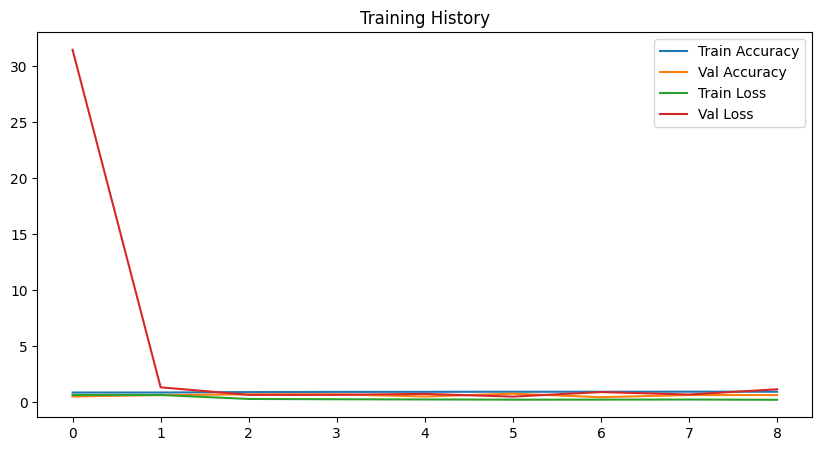

In [5]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training History")
plt.show()

## Model Evaluation

- Generate classification report (precision, recall, F1).
- Plot confusion matrix for diagnostic clarity.

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.86       234
           1       0.93      0.89      0.91       390

    accuracy                           0.89       624
   macro avg       0.88      0.89      0.88       624
weighted avg       0.89      0.89      0.89       624



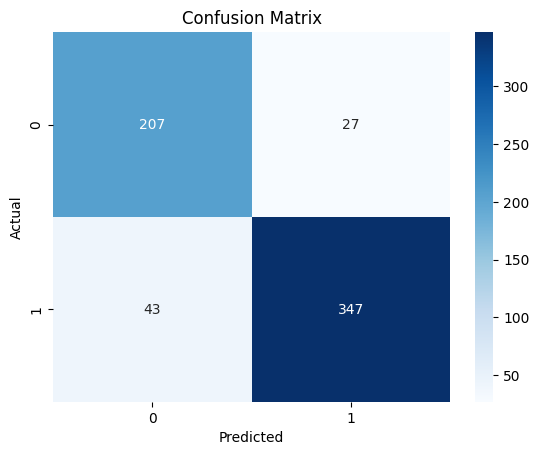

In [6]:
pred_probs = model.predict(testData)
pred_labels = np.round(pred_probs)

print("Classification Report:\n", classification_report(testLabels, pred_labels))

cm = confusion_matrix(testLabels, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### ROC and Precision-Recall Curves

- ROC curve shows trade-off between sensitivity and specificity.
- Precision-Recall curve highlights performance on imbalanced data.

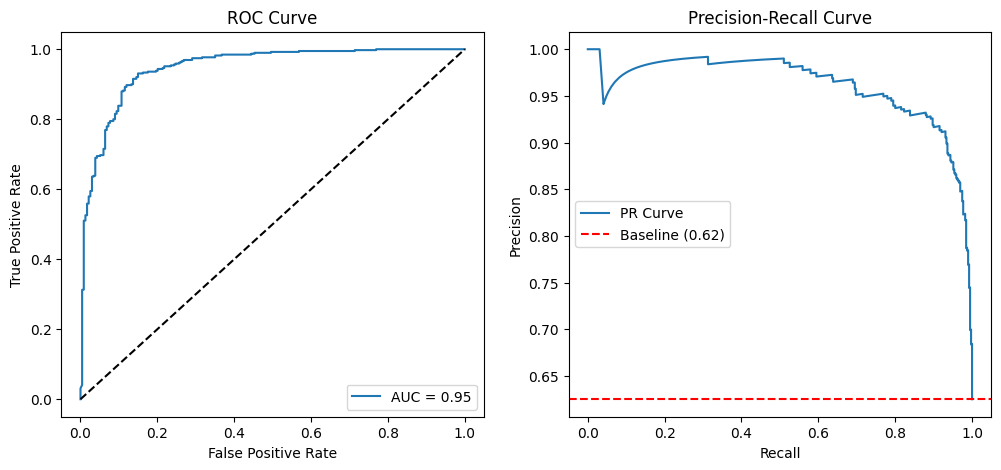

In [8]:
fpr, tpr, _ = roc_curve(testLabels, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

precision, recall, _ = precision_recall_curve(testLabels, pred_probs)
plt.subplot(1,2,2)
plt.plot(recall, precision, label="PR Curve")
baseline = sum(testLabels) / len(testLabels)
plt.axhline(y=baseline, color='red', linestyle='--', label=f"Baseline ({baseline:.2f})")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [9]:
from sklearn.metrics import average_precision_score

avg_precision = average_precision_score(testLabels, pred_probs)
print(f"Average Precision Score: {avg_precision:.2f}")

Average Precision Score: 0.96
